<a href="https://colab.research.google.com/github/VedantPatil-99/deep-learning-notebooks/blob/main/AlexNet_CIFAR10_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
tf.random.set_seed(42)
np.random.seed(42)

Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Dataset loaded. X_train shape: (50000, 32, 32, 3)
Preprocessing CIFAR-10 for AlexNet...
AlexNet Model built successfully
Starting training for 10 epochs...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 85ms/step - accuracy: 0.3959 - loss: 1.6555 - val_accuracy: 0.1356 - val_loss: 4.4719
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.5948 - loss: 1.1375 - val_accuracy: 0.4489 - val_loss: 1.8148
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.6686 - loss: 0.9420 - val_accuracy: 0.5675 - val_loss: 1.3425
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.7156 - loss: 0.8220 - val_accuracy: 0.5801 - val_loss: 1.2821
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.7494 - loss: 0.7299 - val_accuracy: 0.6115 - val_loss: 1.1260
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.7710 - loss: 0.6608 - val_accuracy: 0.6694 - 

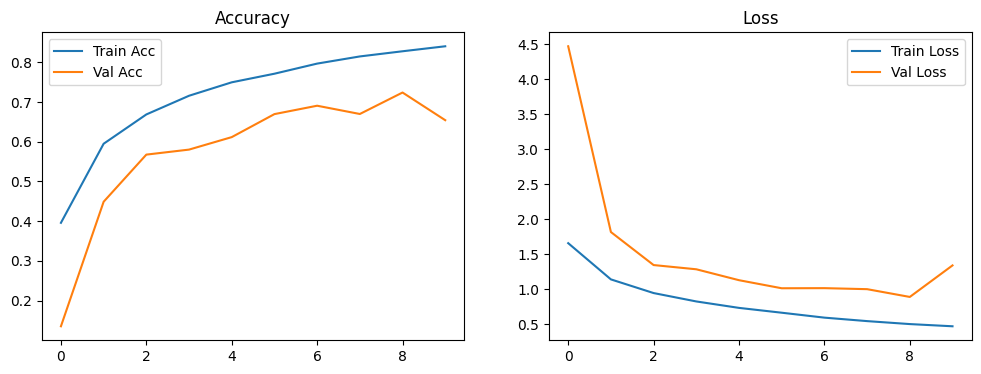

In [3]:
class AlexNetPipeline:
  def __init__(self):
    self.model = None
    self.history = None
    self.X_train = None
    self.X_test = None
    self.y_train = None
    self.y_test = None

  def load_data(self):
    print("Loading CIFAR-10 dataset...")
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
    self.X_train = X_train
    self.y_train = y_train
    self.X_test = X_test
    self.y_test = y_test
    self.class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    print(f"Dataset loaded. X_train shape: {self.X_train.shape}")

  def preprocess_data(self):
    print("Preprocessing CIFAR-10 for AlexNet...")
    # Normalize pixel values to be between 0 and 1
    self.X_train = self.X_train.astype('float32') / 255.0
    self.X_test = self.X_test.astype('float32') / 255.0

    # One-hot encode labels
    self.y_train = tf.keras.utils.to_categorical(self.y_train, 10)
    self.y_test = tf.keras.utils.to_categorical(self.y_test, 10)

  def build_model(self):
    # AlexNet Architecture adapted for 32x32 images
    self.model = keras.Sequential([
      keras.Input(shape=(32, 32, 3)),

      # 1st Conv Block
      layers.Conv2D(96, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'),
      layers.BatchNormalization(),
      layers.MaxPooling2D(pool_size=(2, 2)),

      # 2nd Conv Block
      layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
      layers.BatchNormalization(),
      layers.MaxPooling2D(pool_size=(2, 2)),

      # 3rd, 4th, 5th Conv Layers
      layers.Conv2D(384, kernel_size=(3, 3), activation='relu', padding='same'),
      layers.Conv2D(384, kernel_size=(3, 3), activation='relu', padding='same'),
      layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
      layers.MaxPooling2D(pool_size=(2, 2)),

      # Fully Connected Layers
      layers.Flatten(),
      layers.Dense(4096, activation='relu'),
      layers.Dropout(0.5),
      layers.Dense(4096, activation='relu'),
      layers.Dropout(0.5),
      layers.Dense(10, activation='softmax')
    ])

    self.model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    print("AlexNet Model built successfully")

  def train(self, epochs=15, batch_size=128):
    early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    print(f"Starting training for {epochs} epochs...")
    self.history = self.model.fit(
      self.X_train, self.y_train,
      validation_data=(self.X_test, self.y_test),
      batch_size=batch_size,
      epochs=epochs,
      callbacks=[early_stopping],
      verbose=1
    )

  def evaluate(self):
    scores = self.model.evaluate(self.X_test, self.y_test, verbose=0)
    print(f"Test Loss: {scores[0]:.4f}")
    print(f"Test Accuracy: {scores[1]:.4f}")

  def visualize_performance(self):
    if self.history is None: return
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(self.history.history['accuracy'], label='Train Acc')
    plt.plot(self.history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(self.history.history['loss'], label='Train Loss')
    plt.plot(self.history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

if __name__ == "__main__":
  pipeline = AlexNetPipeline()
  pipeline.load_data()
  pipeline.preprocess_data()
  pipeline.build_model()
  pipeline.train(epochs=10)
  pipeline.evaluate()
  pipeline.visualize_performance()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 932ms/step


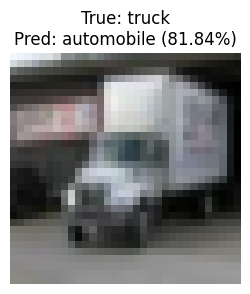

Original Label Index: 9
Predicted Label Index: 1


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Select a random image from the test set
idx = np.random.randint(0, len(pipeline.X_test))
sample_img = pipeline.X_test[idx]
true_label_idx = np.argmax(pipeline.y_test[idx])
true_label = pipeline.class_names[true_label_idx]

# 2. Prepare for prediction: add batch dimension (1, 32, 32, 3)
img_input = np.expand_dims(sample_img, axis=0)

# 3. Perform prediction
predictions = pipeline.model.predict(img_input)
pred_label_idx = np.argmax(predictions)
pred_label = pipeline.class_names[pred_label_idx]
confidence = predictions[0][pred_label_idx]

# 4. Visualize the result
plt.figure(figsize=(3, 3))
plt.imshow(sample_img)
plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2%})")
plt.axis('off')
plt.show()

print(f"Original Label Index: {true_label_idx}")
print(f"Predicted Label Index: {pred_label_idx}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 978ms/step


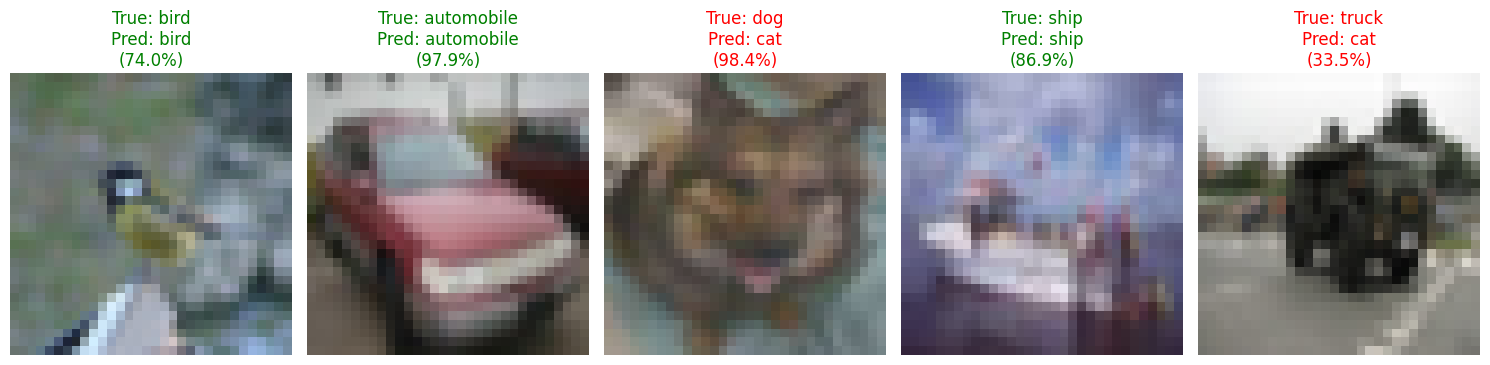

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Select 5 random indices from the test set
num_samples = 5
indices = np.random.choice(len(pipeline.X_test), num_samples, replace=False)

sample_images = pipeline.X_test[indices]
sample_labels = pipeline.y_test[indices]

# 2. Perform batch prediction
predictions = pipeline.model.predict(sample_images)

# 3. Visualize the results
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)

    true_idx = np.argmax(sample_labels[i])
    pred_idx = np.argmax(predictions[i])
    confidence = predictions[i][pred_idx]

    color = 'green' if true_idx == pred_idx else 'red'

    plt.imshow(sample_images[i])
    plt.title(f"True: {pipeline.class_names[true_idx]}\nPred: {pipeline.class_names[pred_idx]}\n({confidence:.1%})", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()